In [1]:
import json
import os
from PIL import Image
import supervision as sv
from rfdetr import RFDETRBase
import cv2
import matplotlib.pyplot as plt


In [2]:
# Set Roboflow API Key
os.environ['ROBOFLOW_API_KEY'] = "J1oKKy8ww5yYkJGO3YUZ"

# Define dataset paths - UPDATE THESE PATHS
DATASET_NAME = "underwater_COCO_dataset"

# Define your dataset paths
DATASET_ROOT = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"

# Train paths
train_dir_images = os.path.join(DATASET_ROOT, "train/images")
train_dir_labels = os.path.join(DATASET_ROOT, "train/labels")  # YOLO format labels
output_train_dir = os.path.join(DATASET_ROOT, "train")

# Validation paths
valid_dir_images = os.path.join(DATASET_ROOT, "valid/images")
valid_dir_labels = os.path.join(DATASET_ROOT, "valid/labels")
output_valid_dir = os.path.join(DATASET_ROOT, "valid")

# Test paths
test_dir_images = os.path.join(DATASET_ROOT, "test/images")
test_dir_labels = os.path.join(DATASET_ROOT, "test/labels")
output_test_dir = os.path.join(DATASET_ROOT, "test")


print("Dataset paths configured successfully!")


Dataset paths configured successfully!


In [3]:
# Define categories for the aquatic dataset
categories = [
    {"id": 0, "name": 'fish', "supercategory": "animal"}, 
    {"id": 1, "name": 'jellyfish', "supercategory": "animal"}, 
    {"id": 2, "name": "penguin", "supercategory": "animal"}, 
    {"id": 3, "name": "puffer_fish", "supercategory": "animal"}, 
    {"id": 4, "name": "shark", "supercategory": "animal"}, 
    {"id": 5, "name": "stingray", "supercategory": "animal"}, 
    {"id": 6, "name": "starfish", "supercategory": "animal"}
]

print("Categories defined:")
for cat in categories:
    print(f"  ID {cat['id']}: {cat['name']}")


Categories defined:
  ID 0: fish
  ID 1: jellyfish
  ID 2: penguin
  ID 3: puffer_fish
  ID 4: shark
  ID 5: stingray
  ID 6: starfish


In [4]:
def convert_yolo_to_coco(images_dir, labels_dir, output_dir, categories):
    """
    Convert YOLO format annotations to COCO format
    
    Args:
        images_dir: Directory containing images
        labels_dir: Directory containing YOLO format labels (.txt files)
        output_dir: Directory to save COCO format annotations
        categories: List of category dictionaries
    """
    # Create the COCO format schema
    coco_dataset = {
        "info": {},
        "licenses": [],
        "categories": categories,
        "images": [],
        "annotations": [],
    }
    
    annotation_id = 0
    image_id_counter = 0
    
    # Iterate through all images in the directory
    for image_file in os.listdir(images_dir):
        if not image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        image_path = os.path.join(images_dir, image_file)
        
        # Open image to get dimensions
        try:
            image = Image.open(image_path)
            width, height = image.size
        except Exception as e:
            print(f"Error opening image {image_file}: {e}")
            continue
        
        image_id = image_id_counter
        
        # Create image dictionary
        image_dict = {
            "id": image_id,
            "width": width,
            "height": height,
            "file_name": image_file,
        }
        
        coco_dataset["images"].append(image_dict)
        
        # Read corresponding YOLO annotation file
        label_file = os.path.splitext(image_file)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_file)
        
        if os.path.exists(label_path):
            try:
                with open(label_path, 'r') as f:
                    annotations = f.readlines()
                
                for ann in annotations:
                    parts = ann.strip().split()
                    if len(parts) < 5:
                        continue
                        
                    category_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                    
                    # Convert YOLO format (normalized center coordinates) to COCO format (absolute corner coordinates)
                    x_min = int((x - w/2) * width)
                    y_min = int((y - h/2) * height)
                    x_max = int((x + w/2) * width)
                    y_max = int((y + h/2) * height)
                    
                    bbox_width = x_max - x_min
                    bbox_height = y_max - y_min
                    
                    # Create annotation dictionary
                    ann_dict = {
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": category_id,
                        "bbox": [x_min, y_min, bbox_width, bbox_height],
                        "area": bbox_height * bbox_width,
                        "iscrowd": 0,
                    }
                    
                    coco_dataset["annotations"].append(ann_dict)
                    annotation_id += 1
            except Exception as e:
                print(f"Error processing label file {label_file}: {e}")
        
        image_id_counter += 1
    
    # Save COCO format annotations
    output_file = os.path.join(output_dir, '_annotations.coco.json')
    with open(output_file, 'w') as f:
        json.dump(coco_dataset, f, indent=2)
    
    print(f"Converted {image_id_counter} images with {annotation_id} annotations")
    print(f"Saved to: {output_file}")
    return coco_dataset

print("Conversion function defined successfully!")


Conversion function defined successfully!


In [5]:
# Convert training set
print("Converting training set...")
train_coco = convert_yolo_to_coco(
    train_dir_images, 
    train_dir_labels, 
    output_train_dir, 
    categories
)

# Convert validation set
print("\nConverting validation set...")
valid_coco = convert_yolo_to_coco(
    valid_dir_images, 
    valid_dir_labels, 
    output_valid_dir, 
    categories
)

# Convert test set
print("\nConverting test set...")
test_coco = convert_yolo_to_coco(
    test_dir_images, 
    test_dir_labels, 
    output_test_dir, 
    categories
)

print("\n✅ All conversions completed!")


Converting training set...
Converted 448 images with 3324 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\train\_annotations.coco.json

Converting validation set...
Converted 127 images with 909 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\valid\_annotations.coco.json

Converting test set...
Converted 63 images with 584 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\test\_annotations.coco.json

✅ All conversions completed!


In [6]:
# Initialize RF-DETR Base model
model = RFDETRBase()

# Training configuration
DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models"
EPOCHS = 50
BATCH_SIZE = 4  # Adjust based on GPU memory (T4: 4, A100: 16)
GRAD_ACCUM_STEPS = 16  # Keep total batch size = batch_size * grad_accum_steps = 16
LEARNING_RATE = 1e-4

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# History callback to track metrics
history = []

def callback_on_epoch_end(data):
    """Callback function to store training metrics"""
    history.append(data)
    print(f"Epoch {data.get('epoch', 0)}: Train Loss = {data.get('train_loss', 0):.4f}, "
          f"Val Loss = {data.get('test_loss', 0):.4f}, mAP = {data.get('test_map', 0):.4f}")

# Register callback
model.callbacks["on_fit_epoch_end"].append(callback_on_epoch_end)

print("Model initialized and ready for training!")
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Grad Accum: {GRAD_ACCUM_STEPS}")


Loading pretrain weights
Model initialized and ready for training!
Dataset: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR
Output: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\trained_models
Epochs: 50, Batch Size: 4, Grad Accum: 16


In [7]:
# Start training
print("Starting training...")
model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    output_dir=OUTPUT_DIR,
    use_ema=True,
    tensorboard=True,  # Enable to visualize layer-wise CKA losses
    early_stopping=True,
    early_stopping_patience=10,
    amp=True,
    device='cuda',
    num_workers=0,
    multi_scale=False,
    resolution=448,
)

print("✅ Training completed!")
print(f"Model checkpoints saved to: {OUTPUT_DIR}")


Starting training...
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\trained_models' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: f108f8587ac339368a233cb59e7faff800a7c3ed, status: has uncommited changes, branch: develop

Namespace(num_classes=7, grad_accum_steps=16, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer

Epoch: [0]  [0/7]  eta: 0:02:03  lr: 0.000100  class_error: 100.00  loss: 7.4557 (7.4557)  loss_ce: 0.8589 (0.8589)  loss_bbox: 0.1879 (0.1879)  loss_giou: 0.7653 (0.7653)  loss_ce_0: 0.8490 (0.8490)  loss_bbox_0: 0.2030 (0.2030)  loss_giou_0: 0.8059 (0.8059)  loss_ce_1: 0.8429 (0.8429)  loss_bbox_1: 0.1941 (0.1941)  loss_giou_1: 0.7921 (0.7921)  loss_ce_enc: 0.8651 (0.8651)  loss_bbox_enc: 0.2359 (0.2359)  loss_giou_enc: 0.8556 (0.8556)  loss_ce_unscaled: 0.8589 (0.8589)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.0376 (0.0376)  loss_giou_unscaled: 0.3827 (0.3827)  cardinality_error_unscaled: 3891.5000 (3891.5000)  loss_ce_0_unscaled: 0.8490 (0.8490)  loss_bbox_0_unscaled: 0.0406 (0.0406)  loss_giou_0_unscaled: 0.4029 (0.4029)  cardinality_error_0_unscaled: 3880.0000 (3880.0000)  loss_ce_1_unscaled: 0.8429 (0.8429)  loss_bbox_1_unscaled: 0.0388 (0.0388)  loss_giou_1_unscaled: 0.3961 (0.3961)  cardinality_error_1_unscaled: 3890.7500 (3890.7500)  loss_ce_enc_unscal

Test:  [ 0/32]  eta: 0:00:27  class_error: 100.00  loss: 7.2765 (7.2765)  loss_ce: 1.2891 (1.2891)  loss_bbox: 0.1778 (0.1778)  loss_giou: 0.3595 (0.3595)  loss_ce_0: 1.2812 (1.2812)  loss_bbox_0: 0.1940 (0.1940)  loss_giou_0: 0.3642 (0.3642)  loss_ce_1: 1.2812 (1.2812)  loss_bbox_1: 0.1877 (0.1877)  loss_giou_1: 0.3633 (0.3633)  loss_ce_enc: 1.1875 (1.1875)  loss_bbox_enc: 0.1985 (0.1985)  loss_giou_enc: 0.3924 (0.3924)  loss_ce_unscaled: 1.2891 (1.2891)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.0356 (0.0356)  loss_giou_unscaled: 0.1798 (0.1798)  cardinality_error_unscaled: 259.5000 (259.5000)  loss_ce_0_unscaled: 1.2812 (1.2812)  loss_bbox_0_unscaled: 0.0388 (0.0388)  loss_giou_0_unscaled: 0.1821 (0.1821)  cardinality_error_0_unscaled: 280.5000 (280.5000)  loss_ce_1_unscaled: 1.2812 (1.2812)  loss_bbox_1_unscaled: 0.0375 (0.0375)  loss_giou_1_unscaled: 0.1817 (0.1817)  cardinality_error_1_unscaled: 285.0000 (285.0000)  loss_ce_enc_unscaled: 1.1875 (1.1875)  lo

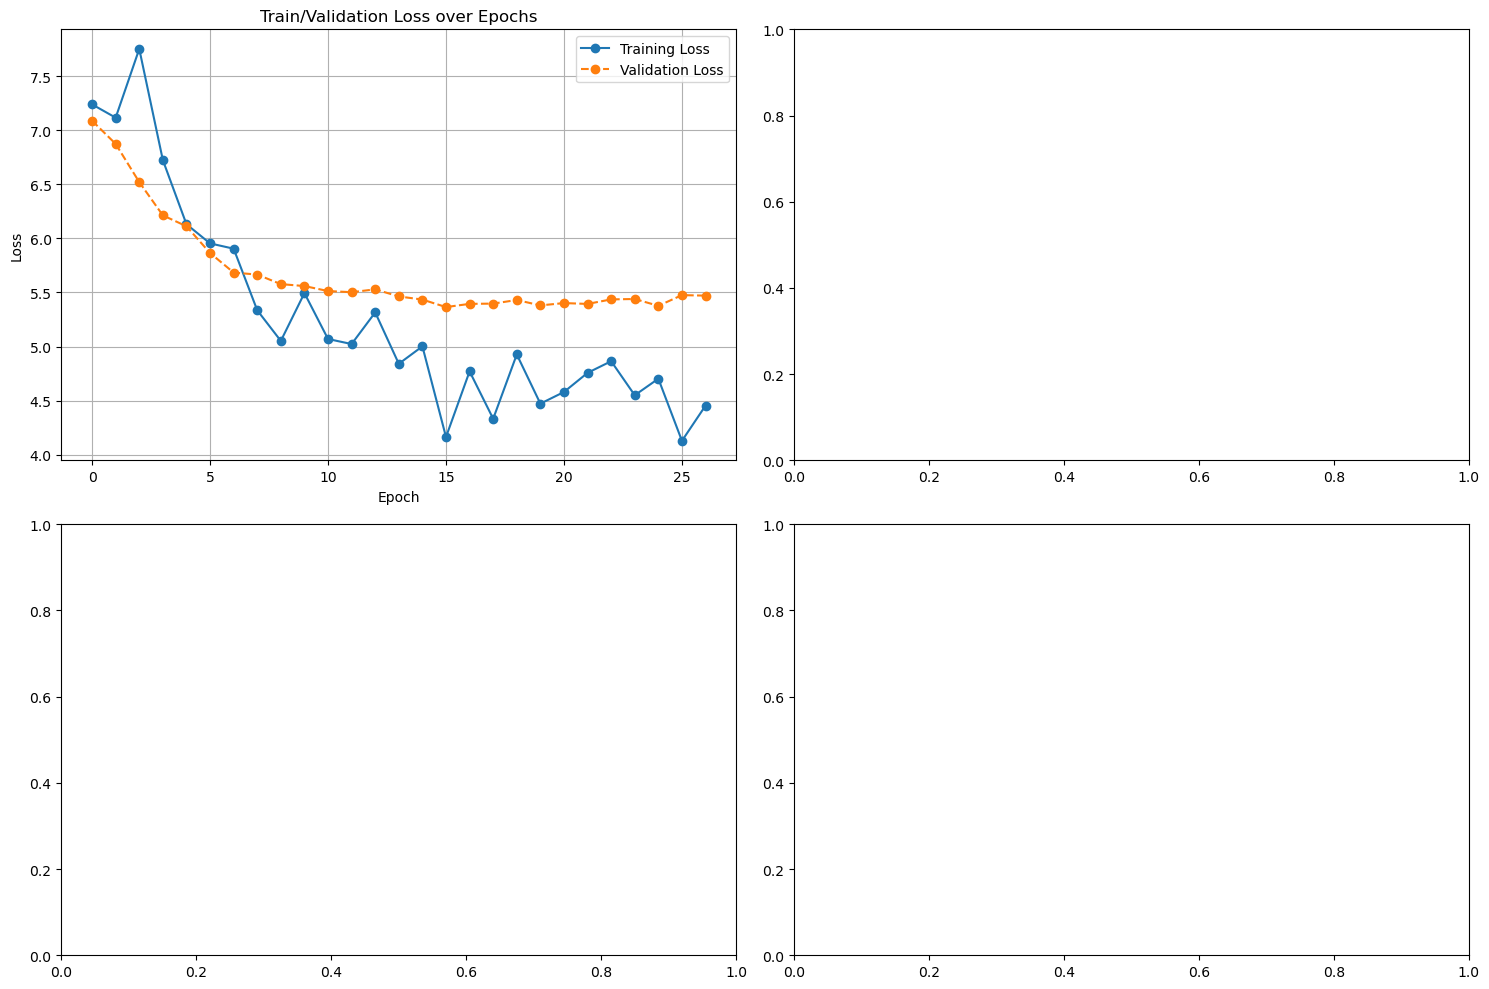

Training metrics plot saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\trained_models/training_metrics.png


In [8]:
import pandas as pd

# Convert history to DataFrame for plotting
df = pd.DataFrame(history)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training and Validation Loss
axes[0, 0].plot(df['epoch'], df['train_loss'], label='Training Loss', marker='o', linestyle='-')
axes[0, 0].plot(df['epoch'], df['test_loss'], label='Validation Loss', marker='o', linestyle='--')
axes[0, 0].set_title('Train/Validation Loss over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: mAP
if 'test_map' in df.columns:
    axes[0, 1].plot(df['epoch'], df['test_map'], label='Validation mAP', marker='o', color='green')
    axes[0, 1].set_title('Validation mAP over Epochs')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

# Plot 3: Learning Rate
if 'lr' in df.columns:
    axes[1, 0].plot(df['epoch'], df['lr'], label='Learning Rate', marker='o', color='orange')
    axes[1, 0].set_title('Learning Rate over Epochs')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Plot 4: EMA vs Regular mAP comparison
if 'test_map' in df.columns and 'test_map_ema' in df.columns:
    axes[1, 1].plot(df['epoch'], df['test_map'], label='Regular mAP', marker='o')
    axes[1, 1].plot(df['epoch'], df['test_map_ema'], label='EMA mAP', marker='o')
    axes[1, 1].set_title('Regular vs EMA mAP Comparison')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Training metrics plot saved to: {OUTPUT_DIR}/training_metrics.png")


In [9]:
# Load the best checkpoint for inference
CHECKPOINT_PATH = f"{OUTPUT_DIR}/checkpoint_best_total.pth"

# Initialize model with trained weights
trained_model = RFDETRBase(pretrain_weights=CHECKPOINT_PATH)

print(f"✅ Loaded trained model from: {CHECKPOINT_PATH}")
print("Model ready for inference!")


Loading pretrain weights
✅ Loaded trained model from: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\trained_models/checkpoint_best_total.pth
Model ready for inference!


In [10]:
# Load test dataset using supervision
test_dataset = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\test\\_annotations.coco.json",
)

print(f"Test dataset loaded: {len(test_dataset)} images")

# Select a random test image
import random
random_idx = random.randint(0, len(test_dataset) - 1)
path, image, annotations = test_dataset[random_idx]

# Open image and run inference
test_image = Image.open(path)
detections = trained_model.predict(test_image, threshold=0.6)

print(f"\nInference on image: {path}")
print(f"Detected {len(detections)} objects")


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Test dataset loaded: 63 images

Inference on image: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR/test\IMG_2380_jpeg_jpg.rf.a23809682eb1466c1136ca0f55de8fb5.jpg
Detected 4 objects


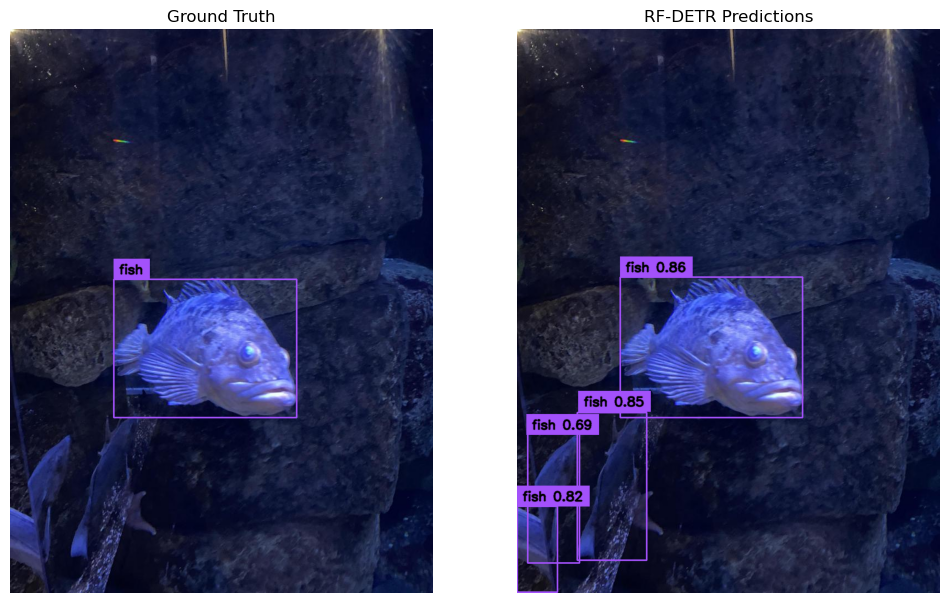

In [11]:
# Calculate optimal text scale and thickness
text_scale = sv.calculate_optimal_text_scale(resolution_wh=test_image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=test_image.size)

# Create annotators
bbox_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_thickness=thickness,
    smart_position=True
)

# Prepare labels for ground truth
annotations_labels = [
    f"{test_dataset.classes[class_id]}"
    for class_id in annotations.class_id
]

# Prepare labels for detections
detections_labels = [
    f"{test_dataset.classes[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Annotate ground truth
annotation_image = test_image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

# Annotate predictions
detections_image = test_image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

# Plot side-by-side comparison
sv.plot_images_grid(
    images=[annotation_image, detections_image], 
    grid_size=(1, 2), 
    titles=["Ground Truth", "RF-DETR Predictions"]
)


In [12]:
# Run inference on video file
def process_video_with_rfdetr(source_video, output_video, model, categories, threshold=0.6):
    """
    Process video with RF-DETR model and save annotated output
    
    Args:
        source_video: Path to input video
        output_video: Path to save output video
        model: Trained RF-DETR model
        categories: List of category dictionaries
        threshold: Detection confidence threshold
    """
    def callback(frame, index):
        annotated_frame = frame.copy()
        
        # Run detection on frame
        detections = model.predict(annotated_frame, threshold=threshold)
        
        # Create labels
        labels = [
            f"{categories[class_id]['name']} {confidence:.2f}"
            for class_id, confidence in zip(detections.class_id, detections.confidence)
        ]
        
        # Annotate frame
        annotated_frame = sv.BoxAnnotator().annotate(annotated_frame, detections)
        annotated_frame = sv.LabelAnnotator().annotate(annotated_frame, detections, labels)
        
        return annotated_frame
    
    # Process video
    sv.process_video(
        source_path=source_video,
        target_path=output_video,
        callback=callback,
    )
    
    print(f"✅ Video processed and saved to: {output_video}")

SOURCE_VIDEO = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\output_video-2.mp4"
OUTPUT_VIDEO = "./output_annotations_aquatic.mp4"
process_video_with_rfdetr(SOURCE_VIDEO, OUTPUT_VIDEO, trained_model, categories)


✅ Video processed and saved to: ./output_annotations_aquatic.mp4


In [13]:
# Comprehensive evaluation on test set
print("Running comprehensive evaluation on test set...")

all_detections = []
all_ground_truths = []

for idx in range(len(test_dataset)):
    path, image, annotations = test_dataset[idx]
    test_image = Image.open(path)
    detections = trained_model.predict(test_image, threshold=0.5)
    
    all_detections.append(detections)
    all_ground_truths.append(annotations)

print(f"✅ Evaluated {len(test_dataset)} test images")
print(f"Total detections: {sum(len(d) for d in all_detections)}")
print(f"Total ground truth objects: {sum(len(g) for g in all_ground_truths)}")


Running comprehensive evaluation on test set...
✅ Evaluated 63 test images
Total detections: 473
Total ground truth objects: 584


In [14]:
model = RFDETRBase(pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\checkpoint_best_total.pth")

Loading pretrain weights


In [15]:
import supervision as sv
DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"
from PIL import Image

Image.open("D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\metrics_plot.png")


ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

In [16]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

model.optimize_for_inference()
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    # Open and convert image to RGB (ensures 3 channels)
    image = Image.open(path) # This fixes the channel issue
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
100%|██████████| 63/63 [00:19<00:00,  3.21it/s]


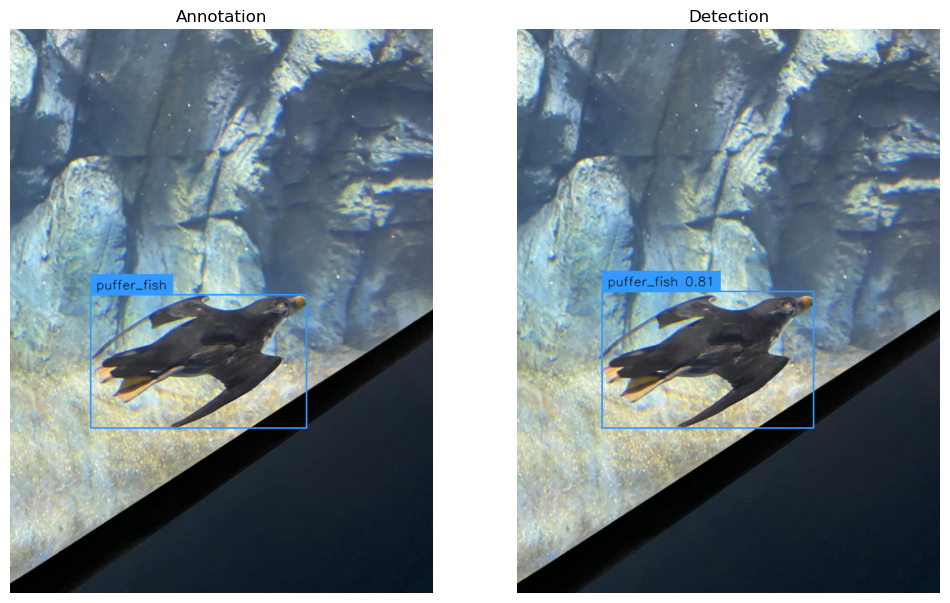

In [17]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])